In [2]:
import ta
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


print("All imports good!") # Import everthing in one cell

All imports good!


In [3]:
# yf.download downloads("Stock name", start="Date you want it from")
df = yf.download("QQQ", start="2019-12-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
# Check for missing values
df.isnull().sum()

# Using shift -1, and then check if current day compare to tomorrow is higher or lower based on Close values, 1 = True, 0 = False
# From 2020-01-02 The closing value was 208, taking the next day's closing value, 2020-01-03, the closing value is 206 so it asks if 206 > 208 = F
# Then it would mark 2020-01-02 as 0 since the next day was not higher than today's. 

# Essentially asking, is tomorrow closing vlaue going to be higher?
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Make a new Column to find out the past 7 day average, .rolling uses the last (n), in this case, 7 rows before it. 
df["Weekly_MA"] = df["Close"].rolling(7).mean()

# Make a new Column to find out the past 30 day average
df["Monthly_MA"] = df["Close"].rolling(30).mean().squeeze()

# Change in volume
df["Volume_Change"] = df["Volume"].pct_change() * 100

# RSA
df["RSI"] = ta.momentum.RSIIndicator(df["Close"].squeeze()).rsi()
df["RSI"].tail()

# Automatically removes NaN rows 
df = df.dropna()

# Check the data
df.tail()


Price,Close,High,Low,Open,Volume,Target,Weekly_MA,Monthly_MA,Volume_Change,RSI
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,,,,,
Date,,,,,,,,,,
2026-04-08,606.090027,609.900024,602.119995,608.710022,63086000,1,583.990008,594.019871,26.302850,58.408137
2026-04-09,610.190002,610.500000,603.030029,605.929993,37837500,1,591.405718,593.829425,-40.022350,60.253506
2026-04-10,611.070007,613.669983,609.580017,611.840027,34038500,1,596.247149,593.915999,-10.040304,60.656994
2026-04-13,617.390015,626.739990,608.109985,609.479980,32972100,1,600.972866,594.278160,-3.132923,63.521111
2026-04-14,628.599976,628.599976,620.099976,620.219971,48253723,0,607.204293,594.987351,46.347133,67.974497


In [8]:

# Testing and Training data
X = df.drop(columns=["Target"])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=250, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy_score(y_test, predictions)


0.5063694267515924

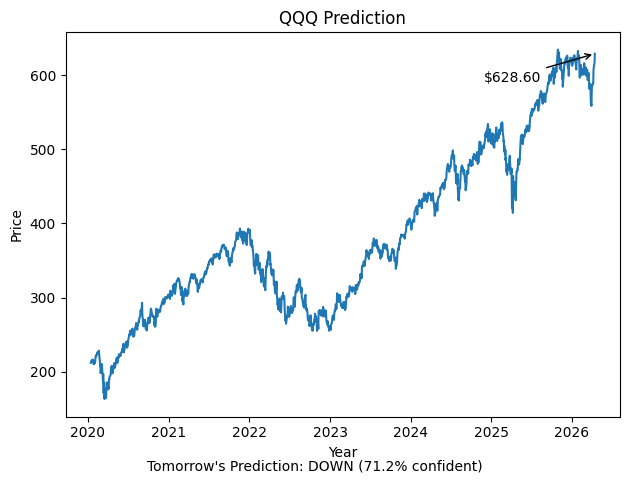

In [6]:
# Creating and labeling graphs
predictions = model.predict(X_test)
accuracy_score(y_test, predictions)

plt.plot(df["Close"])
plt.title("QQQ Prediction")
plt.xlabel("Year")
plt.ylabel("Price")

last_price = df["Close"].iloc[-1].values[0]

# Annotate the plot, this annotation tells us the closing price for current date
plt.annotate(
    f"${last_price:.2f}",
    xy=(df.index[-1], last_price),
    xytext=(-80, -20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)
latest = X.iloc[[-1]]
prediction = model.predict(latest)[0]
confidence = model.predict_proba(latest)[0]

# Predictions
direction = "UP" if prediction == 1 else "DOWN"
conf = confidence[1] if prediction == 1 else confidence[0]

plt.figtext(0.5, 0.01,
            f"Tomorrow's Prediction: {direction} ({conf*100:.1f}% confident)",
            ha="center", fontsize=10)

plt.tight_layout()

plt.show()

In [ ]:
# latest = X.iloc[[-1]]  # grab the last row of our features
# prediction = model.predict(latest)[0]
# confidence = model.predict_proba(latest)[0]
# .predict_proba is probability, return up 60%, down 40%

# This model is only ~50% accurate, so no guarantees that Tomorrow's Prediction is correct

# day 1- 4/9/2026 Price are supposively dropping tomorrow with 64.8% confidence, Today's close $610.190002

# day 2- 4/10/2026 Prices are supposively dropping tomorrown with 56.4% confidence, Today's close $611.070007
# Price went up from Day 1, prediction was not correct

# day 3- 4/11/2026 Market is closed.

# day 4- 4/12/2026 Market is closed.

# day 5- 4/13/2026 Prices are supposively dropping tomorrow with 83.2% confidence, Today's close $617.390015
# Prediction was not correct it went up by ~11$

# day6 - 4/14/2026 Prices are supposively dropping tomorrow with 71.2% confidence, Today's close $628.599976